In [13]:
# 加载数据
import torch
from joblib import dump, load
import torch.utils.data as Data
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
# 参数与配置
torch.manual_seed(100)  # 设置随机种子，以使实验结果具有可重复性
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(100)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def fix_labels():
    """修复标签：重新生成0-1线性标签"""
    from joblib import load, dump

    # 加载特征数据
    train_set = load('../dataresult/train_set.pkl')
    test_set = load('../dataresult/test_set.pkl')

    # 重新生成正确标签（1->0线性下降）
    train_labels_new = torch.linspace(1, 0, train_set.shape[0]).reshape(-1, 1).float()
    test_labels_new = torch.linspace(1, 0, test_set.shape[0]).reshape(-1, 1).float()

    # 保存
    dump(train_labels_new, '../dataresult/train_label.pkl')
    dump(test_labels_new, '../dataresult/test_label.pkl')

    print(f"✅ 标签已修复:")
    print(f"  训练标签: [{train_labels_new.min():.4f}, {train_labels_new.max():.4f}]")
    print(f"  测试标签: [{test_labels_new.min():.4f}, {test_labels_new.max():.4f}]")

    return train_labels_new, test_labels_new

# 加载数据集
def dataloader(batch_size, workers=2):
    # 先修复标签
    fix_labels()

    # 训练集
    train_set = load('../dataresult/train_set.pkl')
    train_label = load('../dataresult/train_label.pkl')

    # 测试集
    test_set = load('../dataresult/test_set.pkl')
    test_label = load('../dataresult/test_label.pkl')

    print(f"📊 数据加载完成:")
    print(f"  训练集: {train_set.shape}, 标签范围: [{train_label.min():.4f}, {train_label.max():.4f}]")
    print(f"  测试集: {test_set.shape}, 标签范围: [{test_label.min():.4f}, {test_label.max():.4f}]")

    # 加载数据
    train_loader = Data.DataLoader(
        dataset=Data.TensorDataset(train_set, train_label),
        batch_size=batch_size,
        num_workers=workers,
        drop_last=False
    )

    test_loader = Data.DataLoader(
        dataset=Data.TensorDataset(test_set, test_label),
        batch_size=batch_size,
        num_workers=workers,
        drop_last=False
    )

    return train_loader, test_loader

batch_size = 32
# 加载数据
train_loader, test_loader = dataloader(batch_size)

print(len(train_loader))
print(len(test_loader))

✅ 标签已修复:
  训练标签: [0.0000, 1.0000]
  测试标签: [0.0000, 1.0000]
📊 数据加载完成:
  训练集: torch.Size([796, 10, 6]), 标签范围: [0.0000, 1.0000]
  测试集: torch.Size([311, 10, 6]), 标签范围: [0.0000, 1.0000]
25
10


In [14]:
# 定义 CNNLSTMModel 模型
class CNNLSTMModel(nn.Module):
    def __init__(self, input_dim, conv_archs, hidden_layer_sizes, output_dim):
        """
        params:
        input_dim          : 输入数据的维度
        conv_archs         : cnn 网络结构
        hidden_layer_sizes : lstm 隐层的数目和维度
        output_dim         : 输出维度数
        """
        super().__init__()
        # 参数
        # CNN参数
        self.conv_arch = conv_archs # cnn网络结构
        self.input_channels = input_dim # 输入通道数
        self.cnn_features = self.make_layers()

        # LSTM参数
        self.num_layers = len(hidden_layer_sizes)  # lstm层数
        self.lstm_layers = nn.ModuleList()  # 用于保存LSTM层的列表
        # 定义第一层LSTM   
        self.lstm_layers.append(nn.LSTM(conv_archs[-1][-1], hidden_layer_sizes[0], batch_first=True))
        # 定义后续的LSTM层
        for i in range(1, self.num_layers):
                self.lstm_layers.append(nn.LSTM(hidden_layer_sizes[i-1], hidden_layer_sizes[i], batch_first=True))

        # 定义线性层
        self.linear  = nn.Linear(hidden_layer_sizes[-1], output_dim)

    # CNN卷积池化结构
    def make_layers(self):
        layers = []
        for (num_convs, out_channels) in self.conv_arch:
            for _ in range(num_convs):
                layers.append(nn.Conv1d(self.input_channels, out_channels, kernel_size=3, padding=1))
                layers.append(nn.ReLU(inplace=True))
                self.input_channels = out_channels
            # layers.append(nn.MaxPool1d(kernel_size=2, stride=2))
        return nn.Sequential(*layers)

    def forward(self, input_seq): 
        # CNN 卷积池化
        # CNN 网络输入[batch, dim, seq_length]
        #改变输入形状
        input_seq = input_seq.permute(0, 2, 1)
        cnn_features = self.cnn_features(input_seq)
        # print(cnn_features.size()) # torch.Size([32, 64, 1])

        # 送入 LSTM 层
        #改变输入形状，lstm 适应网络输入[batch, seq_length, dim]
        lstm_out = cnn_features.permute(0, 2, 1)
        for lstm in self.lstm_layers:
            lstm_out, _= lstm(lstm_out)  ## 进行一次LSTM层的前向传播  # torch.Size([32, 1, 128])
        predict = self.linear(lstm_out[:, -1, :]) # torch.Size([32, 128]  # 仅使用最后一个时间步的输出 
        return predict

In [15]:
# 定义模型参数
input_dim = 6    # 输入维度为14
conv_archs = ((1, 32), (1, 64))   # CNN 层卷积池化结构  类似VGG
hidden_layer_sizes = [64, 128]  # LSTM 层 结构
output_dim = 1 # 输出维度 1

model = CNNLSTMModel(input_dim, conv_archs, hidden_layer_sizes, output_dim)  

# 定义损失函数和优化函数 
loss_function = nn.MSELoss()  # loss
learn_rate = 0.0003
optimizer = torch.optim.Adam(model.parameters(), learn_rate)  # 优化器

# 看下这个网络结构总共有多少个参数
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')

count_parameters(model)

   576
    32
  6144
    64
 16384
 16384
   256
   256
 32768
 65536
   512
   512
   128
     1
______
139553


In [16]:
print(model)

CNNLSTMModel(
  (cnn_features): Sequential(
    (0): Conv1d(6, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU(inplace=True)
    (2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU(inplace=True)
  )
  (lstm_layers): ModuleList(
    (0): LSTM(64, 64, batch_first=True)
    (1): LSTM(64, 128, batch_first=True)
  )
  (linear): Linear(in_features=128, out_features=1, bias=True)
)


In [17]:
# 训练模型
import time
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font", family='Microsoft YaHei')

def model_train(epochs, model, optimizer, loss_function, train_loader, device):
    model = model.to(device)

    # 最低MSE  
    minimum_mse = 1000.
    # 最佳模型
    best_model = model

    train_mse = []     # 记录在训练集上每个epoch的 MSE 指标的变化情况   平均值
  
    # 计算模型运行时间
    start_time = time.time()
    for epoch in range(epochs):
         # 训练
        model.train()
        train_mse_loss = []    #保存当前epoch的MSE loss和
        for seq, labels in train_loader: 
            seq, labels = seq.to(device), labels.to(device)
            # 每次更新参数前都梯度归零和初始化
            optimizer.zero_grad()
            # 前向传播
            y_pred = model(seq)  #   torch.Size([16, 10])
            # 损失计算
            loss = loss_function(y_pred, labels)
            train_mse_loss.append(loss.item()) # 计算 MSE 损失
            # 反向传播和参数更新
            loss.backward()
            optimizer.step()
        #     break
        # break
        # 计算总损失
        train_av_mseloss = np.average(train_mse_loss) # 平均
        train_mse.append(train_av_mseloss)
        print(f'Epoch: {epoch+1:2} train_MSE-Loss: {train_av_mseloss:10.8f}')
       
        # 如果当前模型的 MSE 低于于之前的最佳准确率，则更新最佳模型
        #保存当前最优模型参数
        if train_av_mseloss < minimum_mse:
            minimum_mse = train_av_mseloss
            best_model = model# 更新最佳模型的参数
         
    # 保存最后的参数
    # torch.save(model, 'final_model_cnn_lstm.pt')
    # 保存最好的参数
    torch.save(best_model, 'best_model_cnn_lstm.pt')
    print(f'\nDuration: {time.time() - start_time:.0f} seconds')
    
    # 可视化
    # plt.plot(range(epochs), train_mse, color = 'b',label = 'train_MSE-loss')
    # plt.legend()
    # plt.show()   #显示 lable
    # print(f'min_MSE: {minimum_mse}')

#  模型训练
epochs = 10
model_train(epochs, model, optimizer, loss_function, train_loader, device)

Epoch:  1 train_MSE-Loss: 0.24214741
Epoch:  2 train_MSE-Loss: 0.12302529
Epoch:  3 train_MSE-Loss: 0.09906086
Epoch:  4 train_MSE-Loss: 0.07743137
Epoch:  5 train_MSE-Loss: 0.07105015
Epoch:  6 train_MSE-Loss: 0.05777745
Epoch:  7 train_MSE-Loss: 0.05460263
Epoch:  8 train_MSE-Loss: 0.04534358
Epoch:  9 train_MSE-Loss: 0.04161989
Epoch: 10 train_MSE-Loss: 0.03581005

Duration: 28 seconds


### 第一部分，训练集评估

In [18]:
# 模型预测
# 模型 测试集 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.load('best_model_cnn_lstm.pt')
model = model.to(device)

# 预测数据
origin_data = []
pre_data = []
with torch.no_grad():
        for data, label in train_loader:
            # 原始标签
            origin_lable = label.tolist()
            origin_data += origin_lable
            model.eval()  # 将模型设置为评估模式
            
            # 预测
            data, label = data.to(device), label.to(device)
            train_pred = model(data)  # 对测试集进行预测
            train_pred = train_pred.tolist()
            pre_data += train_pred      

In [19]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# 反归一化处理
# 使用相同的均值和标准差对预测结果进行反归一化处理
# 反标准化
scaler  = load('../dataresult/scaler')
origin_data = scaler.inverse_transform(origin_data)
pre_data = scaler.inverse_transform(pre_data)

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 模型分数
score = r2_score(origin_data, pre_data)
print('训练集上 模型分数-R^2:',score)

print('*'*50)
# 训练集上的预测误差
train_mse = mean_squared_error(origin_data, pre_data)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(origin_data, pre_data)
print('训练数据集上的均方误差-MSE: ',train_mse)
print('训练数据集上的均方根误差-RMSE: ',train_rmse)
print('训练数据集上的平均绝对误差-MAE: ',train_mae)

训练集上 模型分数-R^2: 0.61422344652374
**************************************************
训练数据集上的均方误差-MSE:  0.0026857430366948216
训练数据集上的均方根误差-RMSE:  0.05182415495398668
训练数据集上的平均绝对误差-MAE:  0.03581306185157707


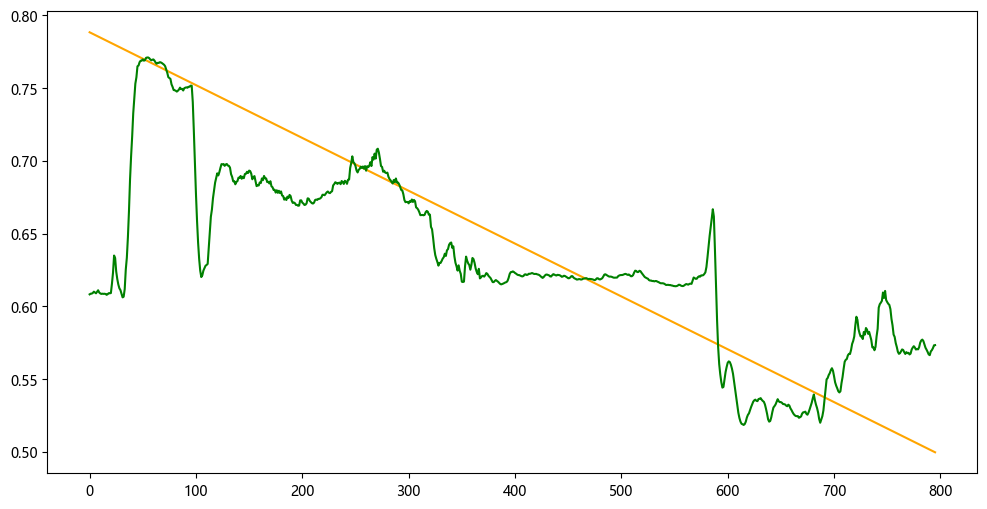

In [20]:
plt.figure(figsize=(12, 6), dpi=100)
plt.plot(origin_data, label='真实寿命',color='orange')  # 真实值
plt.plot(pre_data, label='CNN-LSTM 预测值',color='green')  # 预测值

# 测试集评估

In [21]:
# 模型 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.load('best_model_cnn_lstm.pt')
model = model.to(device)

# 预测数据
test_origin_data = []
test__pre_data = []
with torch.no_grad():
        for data, label in test_loader:
            # 原始标签
            origin_lable = label.tolist()
            test_origin_data += origin_lable
            model.eval()  # 将模型设置为评估模式
            
            # 预测
            data, label = data.to(device), label.to(device)
            pred = model(data)  # 对测试集进行预测
            pred = pred.tolist()
            test__pre_data += pred        

In [22]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# 反归一化处理
# 使用相同的均值和标准差对预测结果进行反归一化处理
# 反标准化
scaler  = load('../dataresult/scaler')
test_origin_data = scaler.inverse_transform(test_origin_data)
test__pre_data = scaler.inverse_transform(test__pre_data)

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 模型分数
score = r2_score(test_origin_data, test__pre_data)
print('测试集上 模型分数-R^2:',score)

print('*'*50)
# 训练集上的预测误差
test_mse = mean_squared_error(test_origin_data, test__pre_data)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(test_origin_data, test__pre_data)
print('测试数据集上的均方误差-MSE: ',test_mse)
print('测试数据集上的均方根误差-RMSE: ',test_rmse)
print('测试数据集上的平均绝对误差-MAE: ',test_mae)

测试集上 模型分数-R^2: -0.15818747267677113
**************************************************
测试数据集上的均方误差-MSE:  0.008094857397572349
测试数据集上的均方根误差-RMSE:  0.08997142545037479
测试数据集上的平均绝对误差-MAE:  0.07559218720443896


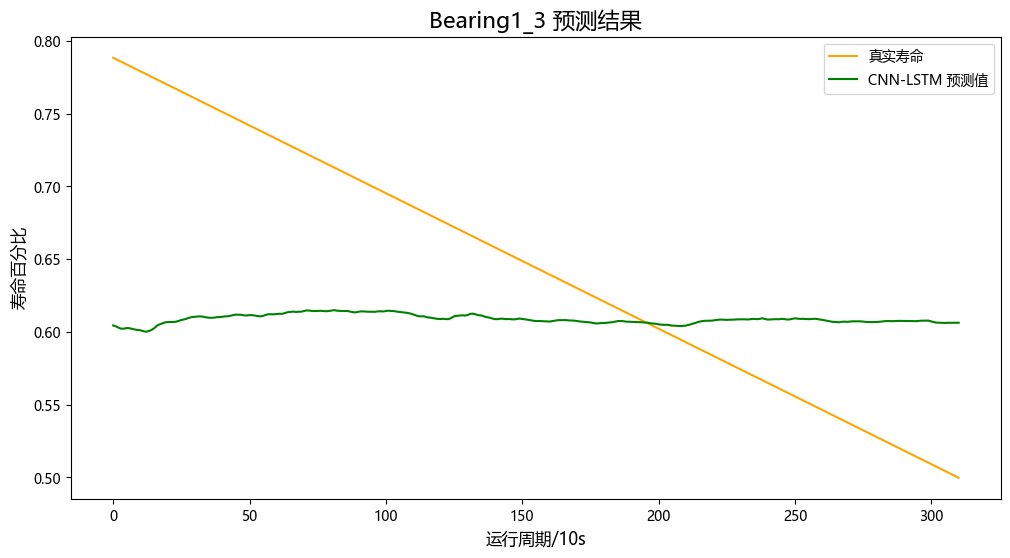

['../画图对比/cnn_lstm_pre']

In [23]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font", family='Microsoft YaHei')

# 可视化结果
plt.figure(figsize=(12, 6), dpi=100)
plt.plot(test_origin_data, label='真实寿命',color='orange')  # 真实值
plt.plot(test__pre_data, label='CNN-LSTM 预测值',color='green')  # 预测值

# plt.plot([-1,170],[2.0*0.7,2.0*0.7],c='black',lw=1,ls='--')  # 临界点直线  可自己调整位置

plt.xlabel('运行周期/10s', fontsize=12)
plt.ylabel('寿命百分比', fontsize=12)
plt.title('Bearing1_3 预测结果', fontsize=16)
plt.legend()
plt.show()

# 保存数据
# 保存数据
dump(test_origin_data, '../画图对比/cnn_lstm_origin') 
dump(test__pre_data, '../画图对比/cnn_lstm_pre')

In [24]:
test__pre_data.shape

(311, 1)